<a href="https://colab.research.google.com/github/HamzaEric/Weather_LSTMs_GRUs/blob/main/Notebooks/Multi_Step_Predictions(Recursive_Direct).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from typing import Tuple
import os, torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

# Last Notebook  Prediction Method

**Core idea**

In the Last Notebook:

$$ \underbrace{[T_{t-6},T_{t-5},\ldots,T_t]}_{S=7} \rightarrow \hat T_{t+1} $$

So the model only had to answer:

“What comes next?”

In this notebook:

$$ [T_{t-6},\ldots,T_t] \rightarrow [\hat T_{t+1},\hat T_{t+2},\ldots,\hat T_{t+H}] $$

Now the model has to answer:

“What are the next H values?”

The important part is that there are two fundamentally different ways to do this.

In [2]:
S = 7  # history window length
H = 7  # forecast horizon

DATA_PATH = "/content/drive/MyDrive/1_Daily_minimum_temps.csv"
print(f"[NB03] Defaults: S={S}, H={H}")

[NB03] Defaults: S=7, H=7


In [3]:
df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%y")  # strict format
df["Temp"] = pd.to_numeric(df["Temp"], errors="coerce")     # coerce bad entries to NaN
df = df.set_index("Date").sort_index()

print("Raw shape (rows, cols):", df.shape)
display(df.head(5))
display(df.tail(5))

print("Date index monotonic increasing? ->", df.index.is_monotonic_increasing)

Raw shape (rows, cols): (3650, 1)


,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


,Temp
Date,
1990-12-27,14.0
1990-12-28,13.6
1990-12-29,13.5
1990-12-30,15.7
1990-12-31,13.0


Date index monotonic increasing? -> True


In [4]:
full_idx = pd.date_range(df.index.min(), df.index.max(), freq="D")
df = df.reindex(full_idx)
df.index.name = "Date"

missing_total = int(df["Temp"].isna().sum())
print(f"Missing days after reindex (before imputation): {missing_total}")


df[df["Temp"].isna()].head()

Missing days after reindex (before imputation): 5


,Temp
Date,
1982-07-20,NaN
1982-07-21,NaN
1984-07-14,NaN
1984-12-31,NaN
1988-12-31,NaN


In [5]:
split_date = pd.Timestamp("1989-01-01")  # test starts here

df_train = df.loc[: split_date - pd.Timedelta(days=1)].copy()
df_test  = df.loc[split_date :].copy()

print(f"Train range: {df_train.index.min().date()} → {df_train.index.max().date()} | rows={len(df_train)}")
print(f" Test range: {df_test.index.min().date()}  → {df_test.index.max().date()}  | rows={len(df_test)}")
print("Missing in train BEFORE impute:", int(df_train['Temp'].isna().sum()))
print("Missing in test  BEFORE impute:", int(df_test['Temp'].isna().sum()))

Train range: 1981-01-01 → 1988-12-31 | rows=2922
 Test range: 1989-01-01  → 1990-12-31  | rows=730
Missing in train BEFORE impute: 5
Missing in test  BEFORE impute: 0


In [6]:
df_train["Temp"] = df_train["Temp"].interpolate(method="time", limit_direction="both")
df_test["Temp"]  = df_test["Temp"].interpolate(method="time",  limit_direction="both")

print("Missing in train AFTER  impute:", int(df_train['Temp'].isna().sum()))
print("Missing in test  AFTER  impute:", int(df_test['Temp'].isna().sum()))

# preview ends to verify continuity
display(df_train.head(3)); display(df_train.tail(3))
display(df_test.head(3));  display(df_test.tail(3))

Missing in train AFTER  impute: 0
Missing in test  AFTER  impute: 0


,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8


,Temp
Date,
1988-12-29,14.8
1988-12-30,14.1
1988-12-31,14.1


,Temp
Date,
1989-01-01,14.3
1989-01-02,17.4
1989-01-03,18.5


,Temp
Date,
1990-12-29,13.5
1990-12-30,15.7
1990-12-31,13.0


In [7]:
# --- Fit MinMaxScaler on TRAIN ONLY (no leakage), then transform both splits ---
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(df_train[["Temp"]])                 # train-only fit

train_scaled = scaler.transform(df_train[["Temp"]])  # ndarray (N_train, 1)
test_scaled  = scaler.transform(df_test[["Temp"]])   # ndarray (N_test, 1)

print("Scaled range (TRAIN) min/max:", float(train_scaled.min()), float(train_scaled.max()))
print("Scaled range (TEST)  min/max:", float(test_scaled.min()),  float(test_scaled.max()))

# print shape of scaled arrays
print("Scaled TRAIN shape (rows, cols):", train_scaled.shape)
print("Scaled  TEST shape (rows, cols):", test_scaled.shape)

Scaled range (TRAIN) min/max: 0.0 1.0
Scaled range (TEST)  min/max: 0.019011406844106463 0.8403041825095058
Scaled TRAIN shape (rows, cols): (2922, 1)
Scaled  TEST shape (rows, cols): (730, 1)


In [8]:
print("Scaled TRAIN shape:", train_scaled[:5])
print("Scaled TRAIN shape - flattened:", train_scaled.reshape(-1)[:5])

Scaled TRAIN shape: [[0.78707224]
 [0.68060837]
 [0.7148289 ]
 [0.55513308]
 [0.60076046]]
Scaled TRAIN shape - flattened: [0.78707224 0.68060837 0.7148289  0.55513308 0.60076046]


### Sanity Check

In [9]:
PLAUDIBLE_MIN, PLAUDIBLE_MAX = -15.0, 45.0   # tweak if your locale differs
BIG_JUMP = 12.0                              # day-to-day jump threshold in °C

def _audit(split_name, s):
    s = s.dropna()
    print(f"\n[{split_name}] rows={len(s)}  min={s.min():.2f}°C  max={s.max():.2f}°C  mean={s.mean():.2f}°C")
    # Range check
    if (s.min() < PLAUDIBLE_MIN) or (s.max() > PLAUDIBLE_MAX):
        print(f"  ⚠ Outside plausible range [{PLAUDIBLE_MIN}, {PLAUDIBLE_MAX}] °C")
    # Day-to-day jumps
    jumps = s.diff().abs()
    big = int((jumps > BIG_JUMP).sum())
    print(f"  Day-to-day jumps > {BIG_JUMP:.0f}°C: {big}  ({100*big/max(1,len(jumps)):.1f}%)")
    # Global z-score outliers
    z = (s - s.mean()) / (s.std(ddof=0) + 1e-8)
    out = int((z.abs() > 4).sum())
    print(f"  |z| > 4 outliers: {out}")
    # Seasonality (month medians; warmest/coldest 3)
    by_mon = s.groupby(s.index.month).median()
    warm = by_mon.sort_values(ascending=False).head(3)
    cold = by_mon.sort_values().head(3)
    wtxt = ", ".join([f"{int(m)}({v:.1f}°C)" for m, v in warm.items()])
    ctxt = ", ".join([f"{int(m)}({v:.1f}°C)" for m, v in cold.items()])
    print(f"  Warmest median months: {wtxt}")
    print(f"  Coldest median months: {ctxt}")

_audit("TRAIN", df_train["Temp"])
_audit("TEST",  df_test["Temp"])


[TRAIN] rows=2922  min=0.00°C  max=26.30°C  mean=11.11°C
  Day-to-day jumps > 12°C: 1  (0.0%)
  |z| > 4 outliers: 0
  Warmest median months: 2(14.9°C), 1(14.6°C), 3(14.2°C)
  Coldest median months: 7(7.0°C), 6(7.3°C), 8(8.3°C)

[TEST] rows=730  min=0.50°C  max=22.10°C  mean=11.47°C
  Day-to-day jumps > 12°C: 0  (0.0%)
  |z| > 4 outliers: 0
  Warmest median months: 2(15.9°C), 1(15.1°C), 3(15.0°C)
  Coldest median months: 7(7.3°C), 8(7.5°C), 6(7.8°C)


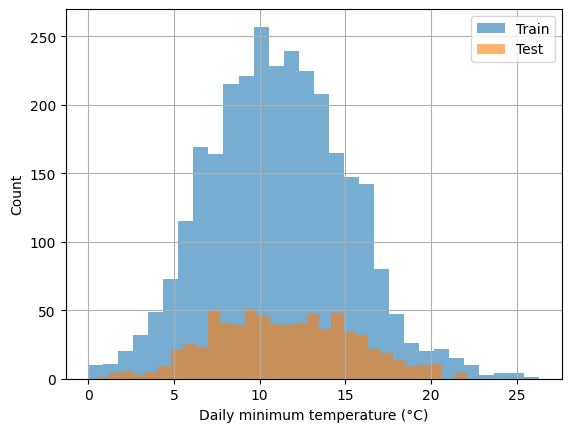

In [12]:
df_train["Temp"].hist(bins=30, alpha=0.6, label="Train"); df_test["Temp"].hist(bins=30, alpha=0.6, label="Test")
plt.xlabel("Daily minimum temperature (°C)"); plt.ylabel("Count"); plt.legend(); plt.show()

# Recursive Strategy

Suppose \(S=7\) and we want \(H=3\).

Initially:

$$ [T_1,T_2,T_3,T_4,T_5,T_6,T_7] $$

The model predicts:

$$ \hat T_8 $$

Then we put \($\hat T_8\$) into the window:

$$ [T_2,T_3,T_4,T_5,T_6,T_7,\boxed{\hat T_8}] $$

Now the model runs again and predicts:

$$ \hat T_9 $$

Then:

$$ [T_3,T_4,T_5,T_6,T_7,\boxed{\hat T_8,\hat T_9}] $$

and predicts:

$$ \hat T_10 $$


```
             ┌───────────────┐
T1 T2 T3 T4 T5 T6 T7 ──────►│ RNN/LSTM/GRU │──► Ť8
                             └───────────────┘
                                      │
                                      ▼
                         feed Ť8 back into window
                                      │
                                      ▼
             T2 T3 T4 T5 T6 T7 Ť8 ──► model ──► Ť9
                                      │
                                      ▼
                         feed Ť9 back into window
                                      │
                                      ▼
             T3 T4 T5 T6 T7 Ť8 Ť9 ──► model ──► Ť10

```
## Direct Multi-Step Forecasting

The **direct forecasting strategy** predicts the entire forecast horizon at once.

If the input window has `S = 7` days and we want to forecast `H = 3` days:

$$
[T_{t-6}, T_{t-5}, \dots, T_t]
\longrightarrow
[\hat T_{t+1}, \hat T_{t+2}, \hat T_{t+3}]
$$

The model produces a **vector of H predictions in one forward pass**.


```text
Input window
(B, S, 1)
    ↓
RNN / LSTM / GRU
    ↓
Hidden states
(B, S, hidden_size)
    ↓
Take last hidden state
(B, hidden_size)
    ↓
Linear(H)
    ↓
Forecast vector
(B, H)
	​

In [14]:
def create_multi_step_sequences(values: np.ndarray, S: int, H: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Convert a 1D (or Nx1) array 'values' into (X, y) pairs for multi-step forecasting.

    Args:
      values: array-like of shape (N,) or (N,1) containing a single time series (scaled or raw).
      S: input window length (history steps).
      H: forecast horizon length (future steps).

    Returns:
      X: ndarray of shape (N_samples, S, 1)   [batch-first windows]
      y: ndarray of shape (N_samples, H)      [multi-step targets]

    Notes:
      - We build windows strictly within the given 'values' segment (no boundary crossing).
      - We keep the final singleton feature dimension so X is ready for batch-first RNN/LSTM/GRU.
    """
    v = values.reshape(-1)  # flatten to 1D array
    N = len(v)
    N_samples = N - (S + H) + 1
    if N_samples <= 0:
        raise ValueError(f"Not enough data points ({N}) for S={S}, H={H}. Need at least S+H samples.")
    X = np.zeros((N_samples, S, 1), dtype=np.float32)
    Y = np.zeros((N_samples, H),   dtype=np.float32)
    for i in range(N_samples):
        X[i, :, 0] = v[i : i + S] # 0 means
        Y[i, :]    = v[i + S : i + S + H]
    return X, Y

In [15]:
X_train_sc, y_train_sc = create_multi_step_sequences(train_scaled, S=S, H=H)
X_test_sc,  y_test_sc  = create_multi_step_sequences(test_scaled,  S=S, H=H)

print("Scaled arrays for modeling:")
print("  X_train_sc:", X_train_sc.shape, "| y_train_sc:", y_train_sc.shape)
print("  X_test_sc :", X_test_sc.shape,  "| y_test_sc :",  y_test_sc.shape)

# print sample values (optional)
print("X_train_sc sample:\n", X_train_sc[:2])
print("y_train_sc sample:\n", y_train_sc[:2])

Scaled arrays for modeling:
  X_train_sc: (2909, 7, 1) | y_train_sc: (2909, 7)
  X_test_sc : (717, 7, 1) | y_test_sc : (717, 7)
X_train_sc sample:
 [[[0.78707224]
  [0.6806084 ]
  [0.7148289 ]
  [0.5551331 ]
  [0.60076046]
  [0.60076046]
  [0.60076046]]

 [[0.6806084 ]
  [0.7148289 ]
  [0.5551331 ]
  [0.60076046]
  [0.60076046]
  [0.60076046]
  [0.66159695]]]
y_train_sc sample:
 [[0.66159695 0.82889736 0.76045626 0.6159696  0.50570345 0.634981
  0.8174905 ]
 [0.82889736 0.76045626 0.6159696  0.50570345 0.634981   0.8174905
  0.95057034]]


In [16]:
def preview_windows_human(df_segment: pd.DataFrame, S: int, H: int, n_rows: int = 3) -> pd.DataFrame:
    vals = df_segment["Temp"].to_numpy().reshape(-1)
    dates = df_segment.index.to_numpy()
    N = len(vals)
    rows = []
    max_i = min(n_rows, N - (S + H) + 1)
    for i in range(max_i):
        X_vals = vals[i : i + S]
        X_dates = dates[i : i + S]
        y_vals = vals[i + S : i + S + H]
        y_dates = dates[i + S : i + S + H]
        rows.append({
            "input_end_date": pd.to_datetime(X_dates[-1]).date(),
            "X (past S days)": [round(float(x), 1) for x in X_vals],
            "y (next H days)": [round(float(y), 1) for y in y_vals],
            "X_dates": [str(pd.to_datetime(d).date()) for d in X_dates],
            "y_dates": [str(pd.to_datetime(d).date()) for d in y_dates],
        })
    return pd.DataFrame(rows)

preview_df = preview_windows_human(df_train, S=S, H=H, n_rows=3)
display(preview_df)

,input_end_date,X (past S days),y (next H days),X_dates,y_dates
0,1981-01-07,"[20.7, 17.9, 18.8, 14.6, 15.8, 15.8, 15.8]","[17.4, 21.8, 20.0, 16.2, 13.3, 16.7, 21.5]","[1981-01-01, 1981-01-02, 1981-01-03, 1981-01-0...","[1981-01-08, 1981-01-09, 1981-01-10, 1981-01-1..."
1,1981-01-08,"[17.9, 18.8, 14.6, 15.8, 15.8, 15.8, 17.4]","[21.8, 20.0, 16.2, 13.3, 16.7, 21.5, 25.0]","[1981-01-02, 1981-01-03, 1981-01-04, 1981-01-0...","[1981-01-09, 1981-01-10, 1981-01-11, 1981-01-1..."
2,1981-01-09,"[18.8, 14.6, 15.8, 15.8, 15.8, 17.4, 21.8]","[20.0, 16.2, 13.3, 16.7, 21.5, 25.0, 20.7]","[1981-01-03, 1981-01-04, 1981-01-05, 1981-01-0...","[1981-01-10, 1981-01-11, 1981-01-12, 1981-01-1..."


# Baselines for H-Step Forecasting

Before comparing **Recursive** and **Direct** forecasting models, we first establish **baselines** (simple yardsticks).

A baseline answers:

> **"Does our fancy model actually perform better than a simple approach?"**

### 1. Persistence Baseline

The simplest approach is to assume that the future will remain equal to the most recently observed value.

\[
\hat{T}_{t+k} = T_t,\qquad k=1,\dots,H
\]

For example, if today's temperature is 24°C:

```text
Day 1 → 24°C
Day 2 → 24°C
Day 3 → 24°C
...
Day 7 → 24°C

```

### 2. 7-Day Mean Baseline

The second baseline uses the average temperature of the previous 7 days.

$$ \hat{T}_{t+k} = \frac{1}{S} \sum_{j=0}^{S-1} T_{t-j}, \qquad k=1,\dots,H $$

With \(S=7\), we calculate the mean of the previous week's temperatures and use that same value for every future step.

In [27]:
X_test_C, y_test_C = create_multi_step_sequences(
    df_test["Temp"].to_numpy().reshape(-1, 1), S=S, H=H
)

print("In °C (for baselines/plots):")
print("  X_test_C:", X_test_C.shape, "| y_test_C:", y_test_C.shape)

In °C (for baselines/plots):
  X_test_C: (717, 7, 1) | y_test_C: (717, 7)


In [28]:
print("X_test_C sample:\n", X_test_C[:2])
print("y_test_C sample:\n", y_test_C[:2])

X_test_C sample:
 [[[14.3]
  [17.4]
  [18.5]
  [16.8]
  [11.5]
  [ 9.5]
  [12.2]]

 [[17.4]
  [18.5]
  [16.8]
  [11.5]
  [ 9.5]
  [12.2]
  [15.7]]]
y_test_C sample:
 [[15.7 16.3 13.6 12.6 13.8 12.1 13.4]
 [16.3 13.6 12.6 13.8 12.1 13.4 17.3]]


In [29]:
def baseline_persistence(X_windows: np.ndarray, H: int) -> np.ndarray:
    """
    X_windows: (N, S, 1) in °C
    Returns:   (N, H) predictions in °C
    """
    last_vals = X_windows[:, -1, 0]            # T_t
    return np.tile(last_vals.reshape(-1, 1), (1, H))

def baseline_mean_S(X_windows: np.ndarray, H: int) -> np.ndarray:
    """
    X_windows: (N, S, 1) in °C
    Returns:   (N, H) predictions in °C using mean of last S days
    """
    means = X_windows[:, :, 0].mean(axis=1)    # mean over window length S
    return np.tile(means.reshape(-1, 1), (1, H))

# Generate baseline predictions
yhat_pers = baseline_persistence(X_test_C, H=H)
yhat_mean = baseline_mean_S(X_test_C, H=H)

print("Baseline preds shapes:", yhat_pers.shape, yhat_mean.shape)

Baseline preds shapes: (717, 7) (717, 7)


In [30]:
# --- Metrics by horizon (MAE and RMSE in °C) ---
def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

# Compute horizon-wise metrics
rows = []
for k in range(H):  # 0..H-1 corresponds to horizons 1..H
    yk_true = y_test_C[:, k]
    yk_pers = yhat_pers[:, k]
    yk_mean = yhat_mean[:, k]
    rows.append({
        "Horizon": k + 1,
        "Persistence_MAE": mae(yk_true, yk_pers),
        "Persistence_RMSE": rmse(yk_true, yk_pers),
        "MeanS_MAE": mae(yk_true, yk_mean),
        "MeanS_RMSE": rmse(yk_true, yk_mean),
    })

import pandas as pd
df_base = pd.DataFrame(rows).set_index("Horizon")
df_base_rounded = df_base.round(3)
display(df_base_rounded)

# Also compute the mean across horizons as a compact summary
summary = df_base.mean(axis=0).to_frame(name="Mean over horizons").round(3)
display(summary)


,Persistence_MAE,Persistence_RMSE,MeanS_MAE,MeanS_RMSE
Horizon,,,,
1,1.955,2.484,2.038,2.591
2,2.525,3.212,2.161,2.762
3,2.705,3.430,2.220,2.824
4,2.748,3.464,2.252,2.863
5,2.806,3.489,2.286,2.893
6,2.817,3.500,2.299,2.911
7,2.751,3.486,2.300,2.917


,Mean over horizons
Persistence_MAE,2.615
Persistence_RMSE,3.295
MeanS_MAE,2.222
MeanS_RMSE,2.823


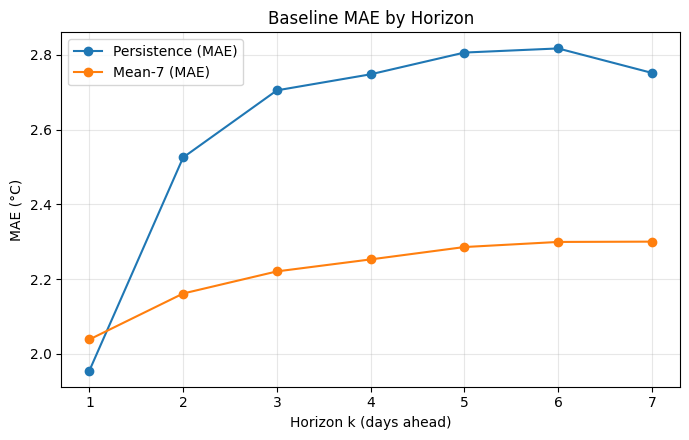

In [33]:
plt.figure(figsize=(7, 4.5))
plt.plot(df_base.index, df_base["Persistence_MAE"], marker="o", label="Persistence (MAE)")
plt.plot(df_base.index, df_base["MeanS_MAE"],      marker="o", label=f"Mean-{S} (MAE)")
plt.xlabel("Horizon k (days ahead)")
plt.ylabel("MAE (°C)")
plt.title("Baseline MAE by Horizon")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Recursive

In [22]:
try:
    model_rnn, model_lstm, model_gru
except NameError:
    # Recreate architectures
    class RNNModel(torch.nn.Module):
        def __init__(self, input_size=1, hidden_size=64, num_layers=1, batch_first=True):
            super().__init__()
            self.rnn = torch.nn.RNN(input_size, hidden_size, num_layers,
                                    nonlinearity="tanh", batch_first=batch_first)
            self.head = torch.nn.Linear(hidden_size, 1)
            self.hidden_size, self.num_layers, self.batch_first = hidden_size, num_layers, batch_first
        def forward(self, x):
            B = x.size(0)
            h0 = x.new_zeros(self.num_layers, B, self.hidden_size)
            out, _ = self.rnn(x, h0)      # (B,S,H)
            return self.head(out[:, -1, :])

    class LSTMModel(torch.nn.Module):
        def __init__(self, input_size=1, hidden_size=64, num_layers=1, batch_first=True):
            super().__init__()
            self.lstm = torch.nn.LSTM(input_size, hidden_size, num_layers, batch_first=batch_first)
            self.head = torch.nn.Linear(hidden_size, 1)
            self.hidden_size, self.num_layers, self.batch_first = hidden_size, num_layers, batch_first
        def forward(self, x):
            B = x.size(0)
            h0 = x.new_zeros(self.num_layers, B, self.hidden_size)
            c0 = x.new_zeros(self.num_layers, B, self.hidden_size)
            out, _ = self.lstm(x, (h0, c0))   # (B,S,H)
            return self.head(out[:, -1, :])

    class GRUModel(torch.nn.Module):
        def __init__(self, input_size=1, hidden_size=64, num_layers=1, batch_first=True):
            super().__init__()
            self.gru  = torch.nn.GRU(input_size, hidden_size, num_layers, batch_first=batch_first)
            self.head = torch.nn.Linear(hidden_size, 1)
            self.hidden_size, self.num_layers, self.batch_first = hidden_size, num_layers, batch_first
        def forward(self, x):
            B = x.size(0)
            h0 = x.new_zeros(self.num_layers, B, self.hidden_size)
            out, _ = self.gru(x, h0)          # (B,S,H)
            return self.head(out[:, -1, :])

    DEVICE = torch.device("cpu")
    model_rnn  = RNNModel(batch_first=True).to(DEVICE)
    model_lstm = LSTMModel(batch_first=True).to(DEVICE)
    model_gru  = GRUModel(batch_first=True).to(DEVICE)

ART_DIR = "/content/drive/MyDrive/rnn_gated_models"
def try_load(model, fname):
    path = os.path.join(ART_DIR, fname)
    if os.path.exists(path):
        model.load_state_dict(torch.load(path, map_location="cpu", weights_only = False))
        print(f" loaded: {fname}")
        return True
    else:
        print(f" missing: {fname} (using random init)")
        return False

ok_rnn  = try_load(model_rnn,  "rnn_state.pkl")
ok_lstm = try_load(model_lstm, "lstm_state.pkl")
ok_gru  = try_load(model_gru,  "gru_state.pkl")

for m in (model_rnn, model_lstm, model_gru):
    m.eval()

 loaded: rnn_state.pkl
 loaded: lstm_state.pkl
 loaded: gru_state.pkl


In [23]:
USE_CLAMP = False

@torch.no_grad()
def rollout_recursive(model, X_windows_scaled, H, clamp=(0.0, 1.0)):
    """
    Args:
      model: trained single-step model that maps (B,S,1) -> (B,1) in scaled space.
      X_windows_scaled: numpy array (N, S, 1) in scaled space for the starting windows.
      H: forecast horizon (number of steps to roll out).
      clamp: tuple (min, max) to clamp predictions if USE_CLAMP is True.
    Returns:
      y_pred_scaled: numpy array (N, H) of scaled forecasts.
    """
    model.eval()
    curr = torch.tensor(X_windows_scaled, dtype=torch.float32)
    N = curr.size(0)
    preds = torch.zeros((N, H), dtype=torch.float32)
    for k in range(H):
        y_hat = model(curr)
        if USE_CLAMP:
            y_hat = y_hat.clamp(min=clamp[0], max=clamp[1])
        preds[:, k] = y_hat.squeeze(1)
        curr = torch.cat([curr[:, 1:, :], y_hat.unsqueeze(-1)], dim=1)
    return preds.numpy()

In [24]:
# 1) Roll out (scaled)
yhat_rnn_sc  = rollout_recursive(model_rnn,  X_test_sc, H) if ok_rnn  else None
yhat_lstm_sc = rollout_recursive(model_lstm, X_test_sc, H) if ok_lstm else None
yhat_gru_sc  = rollout_recursive(model_gru,  X_test_sc, H) if ok_gru  else None

# 2) Inverse-transform to °C for evaluation/plots
def inverse_scale_2d(y_scaled: np.ndarray) -> np.ndarray:
    """Inverse-transform (N,H) using the same scaler trained on train; returns (N,H) in °C."""
    flat = y_scaled.reshape(-1, 1)
    back = scaler.inverse_transform(flat)
    return back.reshape(y_scaled.shape)

yhat_rnn_C  = inverse_scale_2d(yhat_rnn_sc)   if yhat_rnn_sc  is not None else None
yhat_lstm_C = inverse_scale_2d(yhat_lstm_sc)  if yhat_lstm_sc is not None else None
yhat_gru_C  = inverse_scale_2d(yhat_gru_sc)   if yhat_gru_sc  is not None else None

In [31]:
def mae(y_true, y_pred):  return float(np.mean(np.abs(y_true - y_pred)))
def rmse(y_true, y_pred): return float(np.sqrt(np.mean((y_true - y_pred)**2)))

# Baselines from Section 4 (recompute here quickly to be self-contained)
def baseline_persistence(X_windows_C: np.ndarray, H: int) -> np.ndarray:
    last_vals = X_windows_C[:, -1, 0]
    return np.tile(last_vals.reshape(-1, 1), (1, H))

def baseline_mean_S(X_windows_C: np.ndarray, H: int) -> np.ndarray:
    means = X_windows_C[:, :, 0].mean(axis=1)
    return np.tile(means.reshape(-1, 1), (1, H))

yhat_pers = baseline_persistence(X_test_C, H)
yhat_mean = baseline_mean_S(X_test_C, H)

rows = []
for k in range(H):  # horizons 1..H
    true_k = y_test_C[:, k]
    row = {"Horizon": k+1,
           "Persistence_MAE": mae(true_k, yhat_pers[:, k]),
           "MeanS_MAE":      mae(true_k, yhat_mean[:, k])}
    if yhat_rnn_C  is not None:  row["RNN_MAE"]  = mae(true_k, yhat_rnn_C[:,  k])
    if yhat_lstm_C is not None:  row["LSTM_MAE"] = mae(true_k, yhat_lstm_C[:, k])
    if yhat_gru_C  is not None:  row["GRU_MAE"]  = mae(true_k, yhat_gru_C[:,  k])

    row["Persistence_RMSE"] = rmse(true_k, yhat_pers[:, k])
    row["MeanS_RMSE"]       = rmse(true_k, yhat_mean[:, k])
    if yhat_rnn_C  is not None:  row["RNN_RMSE"]  = rmse(true_k, yhat_rnn_C[:,  k])
    if yhat_lstm_C is not None:  row["LSTM_RMSE"] = rmse(true_k, yhat_lstm_C[:, k])
    if yhat_gru_C  is not None:  row["GRU_RMSE"]  = rmse(true_k, yhat_gru_C[:,  k])

    rows.append(row)

df_rec = pd.DataFrame(rows).set_index("Horizon").round(3)
display(df_rec)

# mean across horizons (compact ranking)
mean_summary = df_rec.mean(axis=0).to_frame(name="Mean over horizons").round(3)
display(mean_summary)

,Persistence_MAE,MeanS_MAE,RNN_MAE,LSTM_MAE,GRU_MAE,Persistence_RMSE,MeanS_RMSE,RNN_RMSE,LSTM_RMSE,GRU_RMSE
Horizon,,,,,,,,,,
1,1.955,2.038,1.756,1.803,1.793,2.484,2.591,2.239,2.309,2.282
2,2.525,2.161,2.081,2.107,2.156,3.212,2.762,2.671,2.701,2.754
3,2.705,2.220,2.161,2.195,2.251,3.430,2.824,2.771,2.806,2.886
4,2.748,2.252,2.193,2.241,2.302,3.464,2.863,2.808,2.852,2.954
5,2.806,2.286,2.237,2.285,2.379,3.489,2.893,2.843,2.894,3.023
6,2.817,2.299,2.256,2.298,2.454,3.500,2.911,2.873,2.929,3.093
7,2.751,2.300,2.270,2.323,2.508,3.486,2.917,2.887,2.958,3.158


,Mean over horizons
Persistence_MAE,2.615
MeanS_MAE,2.222
RNN_MAE,2.136
LSTM_MAE,2.179
GRU_MAE,2.263
Persistence_RMSE,3.295
MeanS_RMSE,2.823
RNN_RMSE,2.727
LSTM_RMSE,2.778
GRU_RMSE,2.879


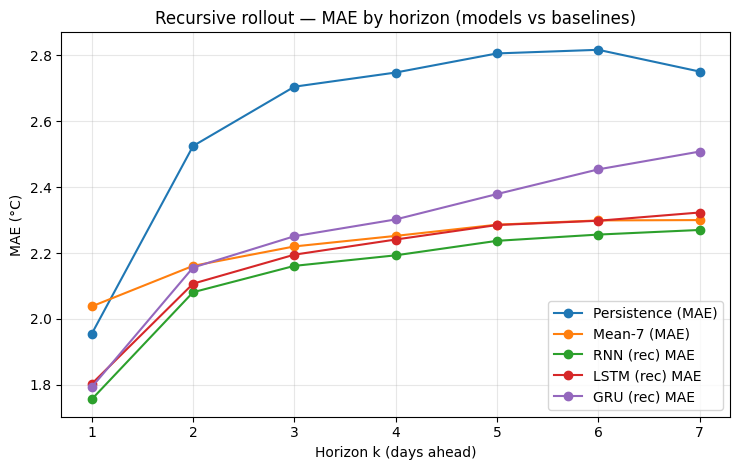

In [34]:
plt.figure(figsize=(7.5, 4.8))
plt.plot(df_rec.index, df_rec["Persistence_MAE"], marker="o", label="Persistence (MAE)")
plt.plot(df_rec.index, df_rec["MeanS_MAE"],      marker="o", label=f"Mean-{S} (MAE)")

if "RNN_MAE" in df_rec:   plt.plot(df_rec.index, df_rec["RNN_MAE"],  marker="o", label="RNN (rec) MAE")
if "LSTM_MAE" in df_rec:  plt.plot(df_rec.index, df_rec["LSTM_MAE"], marker="o", label="LSTM (rec) MAE")
if "GRU_MAE" in df_rec:   plt.plot(df_rec.index, df_rec["GRU_MAE"],  marker="o", label="GRU (rec) MAE")

plt.xlabel("Horizon k (days ahead)")
plt.ylabel("MAE (°C)")
plt.title("Recursive rollout — MAE by horizon (models vs baselines)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Best recursive model by overall RMSE: RNN (RMSE=2.735 °C)


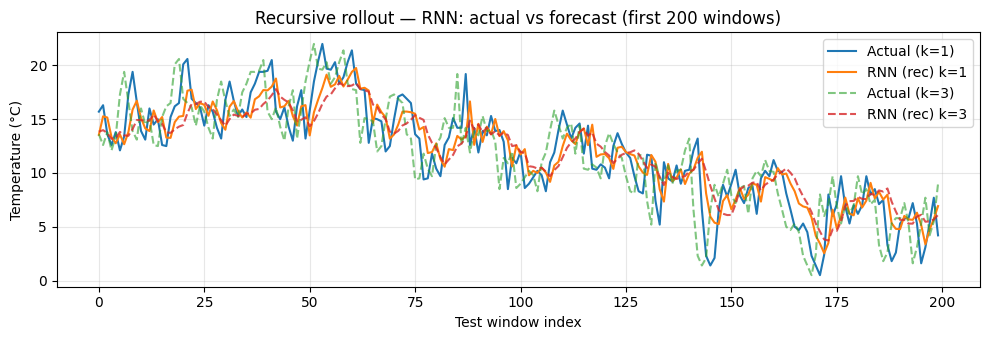

In [35]:
# --- One "actual vs forecast" slice (first ~200 points) for the best recursive model ---
# Choose the model with the lowest mean RMSE across horizons (if available)

candidates = {}
if yhat_rnn_C  is not None:  candidates["RNN"]  = yhat_rnn_C
if yhat_lstm_C is not None:  candidates["LSTM"] = yhat_lstm_C
if yhat_gru_C  is not None:  candidates["GRU"]  = yhat_gru_C

best_name, best_preds = None, None
best_rmse = np.inf
for name, preds in candidates.items():
    m = rmse(y_test_C, preds)  # overall RMSE across all horizons/rows
    if m < best_rmse:
        best_rmse, best_name, best_preds = m, name, preds

print(f"Best recursive model by overall RMSE: {best_name} (RMSE={best_rmse:.3f} °C)")

# Plot the first 200 target points at k=1 (next-day) as an illustration,
# and optionally overlay a longer horizon line too (e.g., k=3).
SLICE = 200
k1 = 0         # horizon index 0 == k=1
k3 = min(2, H-1)

true_k1 = y_test_C[:, k1][:SLICE]
pred_k1 = best_preds[:, k1][:SLICE]

plt.figure(figsize=(10, 3.5))
plt.plot(true_k1,  label="Actual (k=1)", linewidth=1.5)
plt.plot(pred_k1,  label=f"{best_name} (rec) k=1", linewidth=1.5)

# Optional: also show a longer horizon to visualize lag/drift
true_k3 = y_test_C[:, k3][:SLICE]
pred_k3 = best_preds[:, k3][:SLICE]
plt.plot(true_k3,  label="Actual (k=3)", alpha=0.6, linestyle="--")
plt.plot(pred_k3,  label=f"{best_name} (rec) k=3", alpha=0.8, linestyle="--")

plt.title(f"Recursive rollout — {best_name}: actual vs forecast (first {SLICE} windows)")
plt.xlabel("Test window index")
plt.ylabel("Temperature (°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# **Strategy B: <u>Direct</u> Multi-Output Head (seq → $\mathbf{H}$)**

** Idea**
So far we rolled a **one-step** model forward $H$ times (recursive). Now we predict the **entire horizon at once**:

$$
X_t = [T_{t-S+1}, \dots, T_t] \;\longrightarrow\;
\hat{\mathbf{y}}_t =
\big[\hat T_{t+1},\, \hat T_{t+2},\, \dots,\, \hat T_{t+H}\big] \in \mathbb{R}^{H}.
$$

We reuse the same **encoder** (e.g., GRU). From the **last hidden state** \(h_{\text{last}}\) we send one **Linear** head to length $H$:

$$
h_{\text{last}} \in \mathbb{R}^{d}
\;\xrightarrow{\;\;W\in\mathbb{R}^{H\times d}\;\;}\;
\hat{\mathbf{y}} \in \mathbb{R}^{H}.
$$


In [38]:
BATCH = 64

train_ds_direct = TensorDataset(
    torch.tensor(X_train_sc, dtype=torch.float32),
    torch.tensor(y_train_sc, dtype=torch.float32),
)
test_ds_direct = TensorDataset(
    torch.tensor(X_test_sc, dtype=torch.float32),
    torch.tensor(y_test_sc, dtype=torch.float32),
)

train_loader_direct = DataLoader(train_ds_direct, batch_size=BATCH, shuffle=True,  drop_last=False)
test_loader_direct  = DataLoader(test_ds_direct,  batch_size=BATCH, shuffle=False, drop_last=False)

len(train_ds_direct), len(test_ds_direct)

(2909, 717)

In [40]:
class GRUModelDirect(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, H=7, batch_first=True):
        super().__init__()
        self.gru  = nn.GRU(input_size, hidden_size, num_layers, batch_first=batch_first)
        self.head = nn.Linear(hidden_size, H)   # direct multi-output head

    def forward(self, x):
        B = x.size(0)
        h0 = x.new_zeros(self.gru.num_layers, B, self.gru.hidden_size)
        out, _ = self.gru(x, h0)                # (B,S,Hh)
        h_last = out[:, -1, :]                  # (B,Hh)
        y_hat  = self.head(h_last)              # (B,H) in scaled space
        return y_hat

# Instantiate
H = y_train_sc.shape[1]  # ensure we use the same horizon as our data
GRU_model_direct = GRUModelDirect(input_size=1, hidden_size=64, num_layers=1, H=H, batch_first=True)
GRU_model_direct

GRUModelDirect(
  (gru): GRU(1, 64, batch_first=True)
  (head): Linear(in_features=64, out_features=7, bias=True)
)

[ep 01] train MSE=0.01983 | val MSE=0.02035
[ep 05] train MSE=0.01311 | val MSE=0.01155
[ep 10] train MSE=0.01285 | val MSE=0.01120
[ep 15] train MSE=0.01296 | val MSE=0.01114
[ep 20] train MSE=0.01306 | val MSE=0.01147


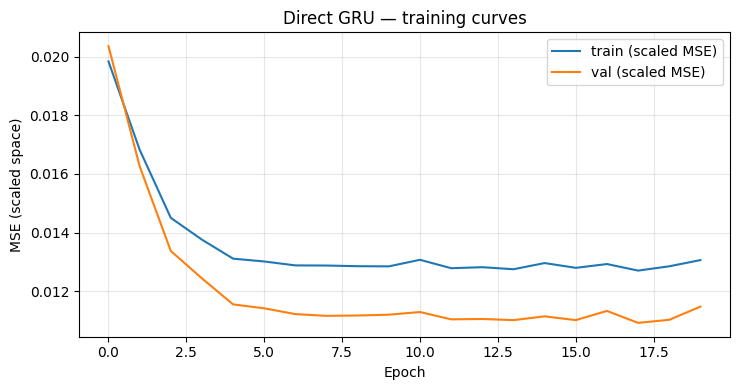

In [41]:
DEVICE   = torch.device("cpu")
EPOCHS   = 20
LR       = 1e-3
CLIP     = 1.0

GRU_model_direct = GRU_model_direct.to(DEVICE)
opt   = torch.optim.Adam(GRU_model_direct.parameters(), lr=LR)
crit  = nn.MSELoss()

def eval_mse_scaled(loader, model):
    model.eval()
    tot, n = 0.0, 0
    with torch.no_grad():
        for xb, yb in loader:
            yb   = yb.to(DEVICE)
            yhat = model(xb.to(DEVICE))
            loss = crit(yhat, yb)
            bs = xb.size(0)
            tot += loss.item() * bs
            n   += bs
    return tot / max(1, n)

train_curve, val_curve = [], []

for ep in range(1, EPOCHS+1):
    GRU_model_direct.train()
    for xb, yb in train_loader_direct:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        yhat = GRU_model_direct(xb)
        loss = crit(yhat, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(GRU_model_direct.parameters(), CLIP)
        opt.step()
    tr = eval_mse_scaled(train_loader_direct, GRU_model_direct)
    va = eval_mse_scaled(test_loader_direct,  GRU_model_direct)
    train_curve.append(tr); val_curve.append(va)
    if ep in (1, 5, 10, 15, 20):
        print(f"[ep {ep:02d}] train MSE={tr:.5f} | val MSE={va:.5f}")

plt.figure(figsize=(7.5,4))
plt.plot(train_curve, label="train (scaled MSE)")
plt.plot(val_curve,   label="val (scaled MSE)")
plt.xlabel("Epoch"); plt.ylabel("MSE (scaled space)")
plt.title("Direct GRU — training curves")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()


In [42]:
@torch.no_grad()
def predict_direct(model, X_sc):
    model.eval()
    yhat_sc = []
    for i in range(0, len(X_sc), BATCH):
        xb = torch.tensor(X_sc[i:i+BATCH], dtype=torch.float32).to(DEVICE)
        yhat_sc.append(model(xb).cpu().numpy())
    return np.vstack(yhat_sc)  # (N,H) scaled

def inverse_scale_2d(y_scaled):
    flat = y_scaled.reshape(-1,1)
    back = scaler.inverse_transform(flat)
    return back.reshape(y_scaled.shape)

def mae(a,b):  return float(np.mean(np.abs(a-b)))
def rmse(a,b): return float(np.sqrt(np.mean((a-b)**2)))

# Predictions
yhat_direct_sc = predict_direct(GRU_model_direct, X_test_sc)      # (N,H) scaled
yhat_direct_C  = inverse_scale_2d(yhat_direct_sc)             # (N,H) °C

# Baselines (from Section 4); rebuild quickly to be self-contained
def baseline_persistence(X_windows_C, H):
    last_vals = X_windows_C[:, -1, 0]
    return np.tile(last_vals.reshape(-1,1), (1,H))
def baseline_mean_S(X_windows_C, H):
    means = X_windows_C[:, :, 0].mean(axis=1)
    return np.tile(means.reshape(-1,1), (1,H))

yhat_pers = baseline_persistence(X_test_C, H)
yhat_mean = baseline_mean_S(X_test_C, H)

# If we already computed recursive predictions earlier, we can compare:
have_rec = False
try:
    _ = yhat_gru_C  # from Section 5
    have_rec = True
except:
    pass

# Horizon-wise table
rows = []
for k in range(H):
    y_true = y_test_C[:, k]
    row = {
        "Horizon": k+1,
        "Direct_GRU_MAE":  mae(y_true, yhat_direct_C[:, k]),
        "Direct_GRU_RMSE": rmse(y_true, yhat_direct_C[:, k]),
        "Persistence_MAE": mae(y_true, yhat_pers[:,    k]),
        "MeanS_MAE":       mae(y_true, yhat_mean[:,    k]),
    }
    if have_rec:
        row["GRU_rec_MAE"] = mae(y_true, yhat_gru_C[:, k])
    rows.append(row)

df_direct = pd.DataFrame(rows).set_index("Horizon").round(3)
display(df_direct)

print("\nMean MAE over horizons:")
display(df_direct[["Direct_GRU_MAE","MeanS_MAE","Persistence_MAE"] + (["GRU_rec_MAE"] if have_rec else [])].mean().to_frame("Mean").round(3))


,Direct_GRU_MAE,Direct_GRU_RMSE,Persistence_MAE,MeanS_MAE,GRU_rec_MAE
Horizon,,,,,
1,1.929,2.460,1.955,2.038,1.793
2,2.168,2.772,2.525,2.161,2.156
3,2.224,2.842,2.705,2.220,2.251
4,2.204,2.825,2.748,2.252,2.302
5,2.257,2.882,2.806,2.286,2.379
6,2.322,2.962,2.817,2.299,2.454
7,2.309,2.947,2.751,2.300,2.508



Mean MAE over horizons:


,Mean
Direct_GRU_MAE,2.202
MeanS_MAE,2.222
Persistence_MAE,2.615
GRU_rec_MAE,2.263


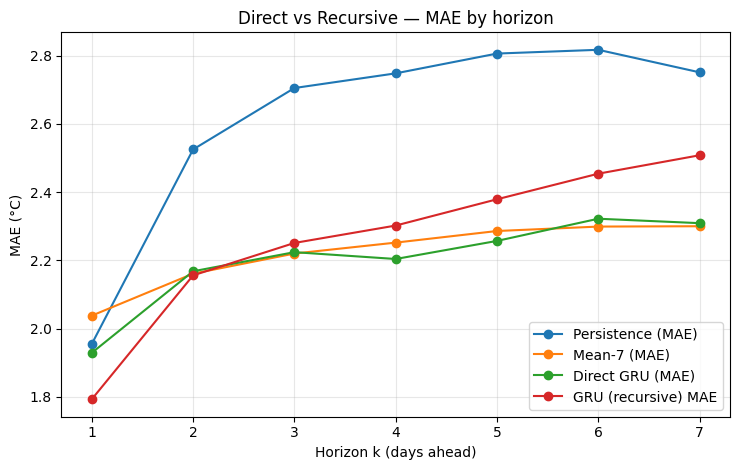

In [43]:
plt.figure(figsize=(7.5, 4.8))
plt.plot(df_direct.index, df_direct["Persistence_MAE"], marker="o", label="Persistence (MAE)")
plt.plot(df_direct.index, df_direct["MeanS_MAE"],      marker="o", label=f"Mean-{S} (MAE)")
plt.plot(df_direct.index, df_direct["Direct_GRU_MAE"], marker="o", label="Direct GRU (MAE)")
if have_rec:
    plt.plot(df_direct.index, df_direct["GRU_rec_MAE"], marker="o", label="GRU (recursive) MAE")
plt.xlabel("Horizon k (days ahead)")
plt.ylabel("MAE (°C)")
plt.title("Direct vs Recursive — MAE by horizon")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
os.makedirs("artifacts", exist_ok=True)
save_path = f"artifacts/nb03_best_{best_name.replace(' ', '_').replace('(', '').replace(')', '').replace('-', '')}.pkl"

torch.save(GRU_model_direct.state_dict(), save_path)
print(f"Saved weights to: {save_path}")

Saved weights to: artifacts/nb03_best_RNN.pkl
